comparing 3 approaches:

Scaling Only (Baseline - 5 mins)
L1 Selection (Main method - 15 mins)
UMAP (Alternative - 15 mins)


## Step 1: Load and Check Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


In [ ]:

data_path = Path("data")


X_train = pd.read_csv("X_train.csv")
X_val = pd.read_csv("X_val.csv")
y_train = pd.read_csv("y_train.csv")
y_val = pd.read_csv("y_val.csv")
X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv")


✅ Data loaded successfully!



In [ ]:

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:   {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"y_test shape:   {y_test.shape}")
print(f"\nNumber of features: {X_train.shape[1]}")
print(f"Training samples:   {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print()

DATA SHAPES
X_train shape: (6158, 20)
X_val shape:   (1414, 20)
X_test shape:   (1589, 20)
y_train shape: (6158, 1)
y_val shape:   (1414, 1)
y_test shape:   (1589, 1)

Number of features: 20
Training samples:   6158
Validation samples: 1414
Test samples: 1589



In [ ]:
print(f"X_train missing values: {X_train.isnull().sum().sum()}")
print(f"X_val missing values:   {X_val.isnull().sum().sum()}")
print(f"X_test missing values:   {X_val.isnull().sum().sum()}")
print(f"y_train missing values: {y_train.isnull().sum().sum()}")
print(f"y_val missing values:   {y_val.isnull().sum().sum()}")
print(f"y_testl missing values:   {y_val.isnull().sum().sum()}")
print()

MISSING VALUES CHECK
X_train missing values: 0
X_val missing values:   0
X_test missing values:   0
y_train missing values: 0
y_val missing values:   0
y_testl missing values:   0



In [ ]:
print(X_train.dtypes.value_counts())
print()

DATA TYPES SUMMARY
float64    11
int64       9
Name: count, dtype: int64



In [ ]:

print("\nClass distribution (y_train):")
print(y_train['popularity_label'].value_counts())
print("\nClass proportions:")
print(y_train['popularity_label'].value_counts(normalize=True))
print()

print("Class distribution (y_val):")
print(y_val['popularity_label'].value_counts())
print("\nClass proportions:")
print(y_val['popularity_label'].value_counts(normalize=True))
print()

print("Class distribution (y_test):")
print(y_test['popularity_label'].value_counts())
print("\nClass proportions:")
print(y_test['popularity_label'].value_counts(normalize=True))
print()

TARGET VARIABLE DISTRIBUTION

Class distribution (y_train):
popularity_label
Not Popular    4310
Popular        1848
Name: count, dtype: int64

Class proportions:
popularity_label
Not Popular    0.699903
Popular        0.300097
Name: proportion, dtype: float64

Class distribution (y_val):
popularity_label
Not Popular    1015
Popular         399
Name: count, dtype: int64

Class proportions:
popularity_label
Not Popular    0.717822
Popular        0.282178
Name: proportion, dtype: float64

Class distribution (y_test):
popularity_label
Not Popular    1140
Popular         449
Name: count, dtype: int64

Class proportions:
popularity_label
Not Popular    0.717432
Popular        0.282568
Name: proportion, dtype: float64



In [ ]:

print("\nFirst 10 features:")
print(X_train.iloc[:, :10].describe())
print()

print("\nX_train (first 5 rows):")
print(X_train.head())
print("\ny_train (first 10 rows):")
print(y_train.head(10))
print()


FEATURE STATISTICS

First 10 features:
       Danceability       Energy  Loudness_norm  Speechiness  Acousticness  \
count   6158.000000  6158.000000    6158.000000  6158.000000   6158.000000   
mean       0.679738     0.635094       0.812788     0.133995      0.222857   
std        0.147769     0.169185       0.076126     0.121321      0.242651   
min        0.073000     0.005000       0.000000     0.023000      0.000000   
25%        0.589000     0.533000       0.780319     0.046000      0.039000   
50%        0.696000     0.649000       0.824133     0.081000      0.131000   
75%        0.787000     0.759000       0.861943     0.191000      0.324750   
max        0.980000     0.996000       1.000000     0.966000      0.994000   

       Instrumentalness      Valence  release_year  release_quarter  \
count       6158.000000  6158.000000   6158.000000      6158.000000   
mean           0.011886     0.480315   2018.504872         2.511692   
std            0.074622     0.224101      1.1

## Step 2: Feature Scaling

In [ ]:
use_scaling = True

if use_scaling:
    
    scaler = StandardScaler()
    scaler.fit(X_train)

    
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
    X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
    
    with open('preprocessing_artifacts/scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)

    print("Scaling applied")
else:
    
    X_train_scaled = X_train.copy()
    X_val_scaled = X_val.copy()
    X_test_scaled = X_test.copy()
    

print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled:   {X_val_scaled.shape}")
print(f"X_val_scaled:   {X_test_scaled.shape}")

Scaling applied
X_train_scaled: (6158, 20)
X_val_scaled:   (1414, 20)
X_val_scaled:   (1589, 20)


In [ ]:
print("\nX_train_scaled (first 5 rows):")
print(X_train_scaled.head())

print("\nX_train_scaled statistics (mean≈0, std≈1):")
print(X_train_scaled.describe())

print("\nComparison - Before vs After Scaling:")
print("\nBefore (Original X_train):")
print(X_train.head(3))
print("\nAfter (X_train_scaled):")
print(X_train_scaled.head(3))

SCALED DATA PREVIEW

X_train_scaled (first 5 rows):
   Danceability    Energy  Loudness_norm  Speechiness  Acousticness  \
0      0.461988 -0.047844       0.162009    -0.576987     -0.378585   
1      1.098170 -0.337492       0.154006     0.033013     -0.902013   
2     -2.211329  0.708787       0.067886     4.937746     -0.580537   
3     -2.218096  1.630931       0.466478    -0.486311     -0.914377   
4     -0.404302 -0.059667      -0.374908     3.453961      0.264366   

   Instrumentalness   Valence  release_year  release_quarter  release_month  \
0         -0.159298  0.194949     -1.330037        -1.339869      -0.999889   
1         -0.159298 -1.295573      1.321426        -1.339869      -1.283506   
2         -0.159298 -0.193301     -0.446216        -0.453532      -0.149039   
3         -0.159298 -1.090291      1.321426         0.432805       0.418194   
4         -0.159298  0.824181     -0.446216        -0.453532      -0.716272   

   release_day_of_week  is_friday_release  is_

## Step 3: Create baseline for preprocessing method (Scaling only)

In [ ]:

y_train_array = y_train['popularity_label'].map({'Popular': 1, 'Not Popular': 0}).values
y_val_array = y_val['popularity_label'].map({'Popular': 1, 'Not Popular': 0}).values


lr_baseline = LogisticRegression(max_iter=1000, random_state=42,class_weight='balanced')
lr_baseline.fit(X_train_scaled, y_train_array)


y_train_pred = lr_baseline.predict(X_train_scaled)
y_val_pred = lr_baseline.predict(X_val_scaled)


train_acc = accuracy_score(y_train_array, y_train_pred)
val_acc = accuracy_score(y_val_array, y_val_pred)
train_f1 = f1_score(y_train_array, y_train_pred)
val_f1 = f1_score(y_val_array, y_val_pred)

print(f"Train - Accuracy: {train_acc:.4f}, F1: {train_f1:.4f}")
print(f"Val   - Accuracy: {val_acc:.4f}, F1: {val_f1:.4f}")
print("\nClassification Report (Val):")
print(classification_report(y_val_array, y_val_pred, target_names=['Not Popular', 'Popular']))

Train - Accuracy: 0.6453, F1: 0.5599
Val   - Accuracy: 0.6450, F1: 0.3548

Classification Report (Val):
              precision    recall  f1-score   support

 Not Popular       0.75      0.76      0.76      1015
     Popular       0.36      0.35      0.35       399

    accuracy                           0.64      1414
   macro avg       0.56      0.55      0.55      1414
weighted avg       0.64      0.64      0.64      1414



## Step 4: L1 Regularisation for features selection

In [ ]:

from sklearn.feature_selection import SelectFromModel


C_values = [0.01, 0.1, 1.0]
results = []


for C in C_values:
    
    lr_l1 = LogisticRegression(penalty='l1', C=C, solver='liblinear', 
                                max_iter=1000, random_state=42, class_weight='balanced')
    lr_l1.fit(X_train_scaled, y_train_array)
    
    
    n_features = np.sum(lr_l1.coef_ != 0)
    
    
    y_val_pred = lr_l1.predict(X_val_scaled)
    
    
    val_acc = accuracy_score(y_val_array, y_val_pred)
    val_f1 = f1_score(y_val_array, y_val_pred)
    
    results.append({
        'C': C,
        'n_features': n_features,
        'val_accuracy': val_acc,
        'val_f1': val_f1
    })
    
    print(f"\nC={C}: {n_features} features | Acc={val_acc:.4f} | F1={val_f1:.4f}")


results_df = pd.DataFrame(results)
best_idx = results_df['val_f1'].idxmax()
best_C = results_df.loc[best_idx, 'C']


print(f"Features selected: {results_df.loc[best_idx, 'n_features']}")


lr_l1_best = LogisticRegression(penalty='l1', C=best_C, solver='liblinear',
                                  max_iter=1000, random_state=42, class_weight='balanced')
lr_l1_best.fit(X_train_scaled, y_train_array)


selector = SelectFromModel(lr_l1_best, prefit=True)
X_train_L1 = selector.transform(X_train_scaled)
X_val_L1 = selector.transform(X_val_scaled)
X_test_L1 = selector.transform(X_test_scaled)


selected_features = X_train_scaled.columns[selector.get_support()].tolist()

print(f"\nSelected features ({len(selected_features)}):")
print(selected_features)


X_train_L1 = pd.DataFrame(X_train_L1, columns=selected_features, index=X_train_scaled.index)
X_val_L1 = pd.DataFrame(X_val_L1, columns=selected_features, index=X_val_scaled.index)
X_test_L1 = pd.DataFrame(X_test_L1, columns=selected_features, index=X_test_scaled.index)

print(f"\nX_train_L1: {X_train_L1.shape}")
print(f"X_val_L1: {X_val_L1.shape}")
print(f"X_test_L1: {X_test_L1.shape}")

L1 FEATURE SELECTION

C=0.01: 10 features | Acc=0.5820 | F1=0.3876

C=0.1: 18 features | Acc=0.6485 | F1=0.3636

C=1.0: 20 features | Acc=0.6457 | F1=0.3569

✅ Best C: 0.01
Features selected: 10

Selected features (10):
['Danceability', 'Loudness_norm', 'Speechiness', 'Valence', 'release_year', 'release_month', 'release_day_of_week', 'is_friday_release', 'artist_avg_rank', 'artist_best_rank']

X_train_L1: (6158, 10)
X_val_L1: (1414, 10)
X_test_L1: (1589, 10)


/opt/miniconda3/envs/AmlSpotify/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/opt/miniconda3/envs/AmlSpotify/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/opt/miniconda3/envs/AmlSpotify/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


L1 FEATURE SELECTION: ALL FEATURES ANALYSIS (C=0.01)

L1 FEATURE SELECTION: ALL FEATURES ANALYSIS (C=0.01)

📊 ALL FEATURES SUMMARY (C=0.01)
--------------------------------------------------------------------------------
Total features: 20
Selected (non-zero): 10
Removed (zero): 10
Selection rate: 50.0%

📌 TOP 20 FEATURES BY IMPORTANCE:
--------------------------------------------------------------------------------
                     Feature  Coefficient  Abs_Coefficient  Selected     Direction
             artist_avg_rank    -0.624376         0.624376      True ↓ Not Popular
            artist_best_rank    -0.343108         0.343108      True ↓ Not Popular
           is_friday_release    -0.171542         0.171542      True ↓ Not Popular
                release_year    -0.067129         0.067129      True ↓ Not Popular
                 Speechiness    -0.058236         0.058236      True ↓ Not Popular
                     Valence     0.058142         0.058142      True     ↑ Popular
                Danceability     0.029190         0.0

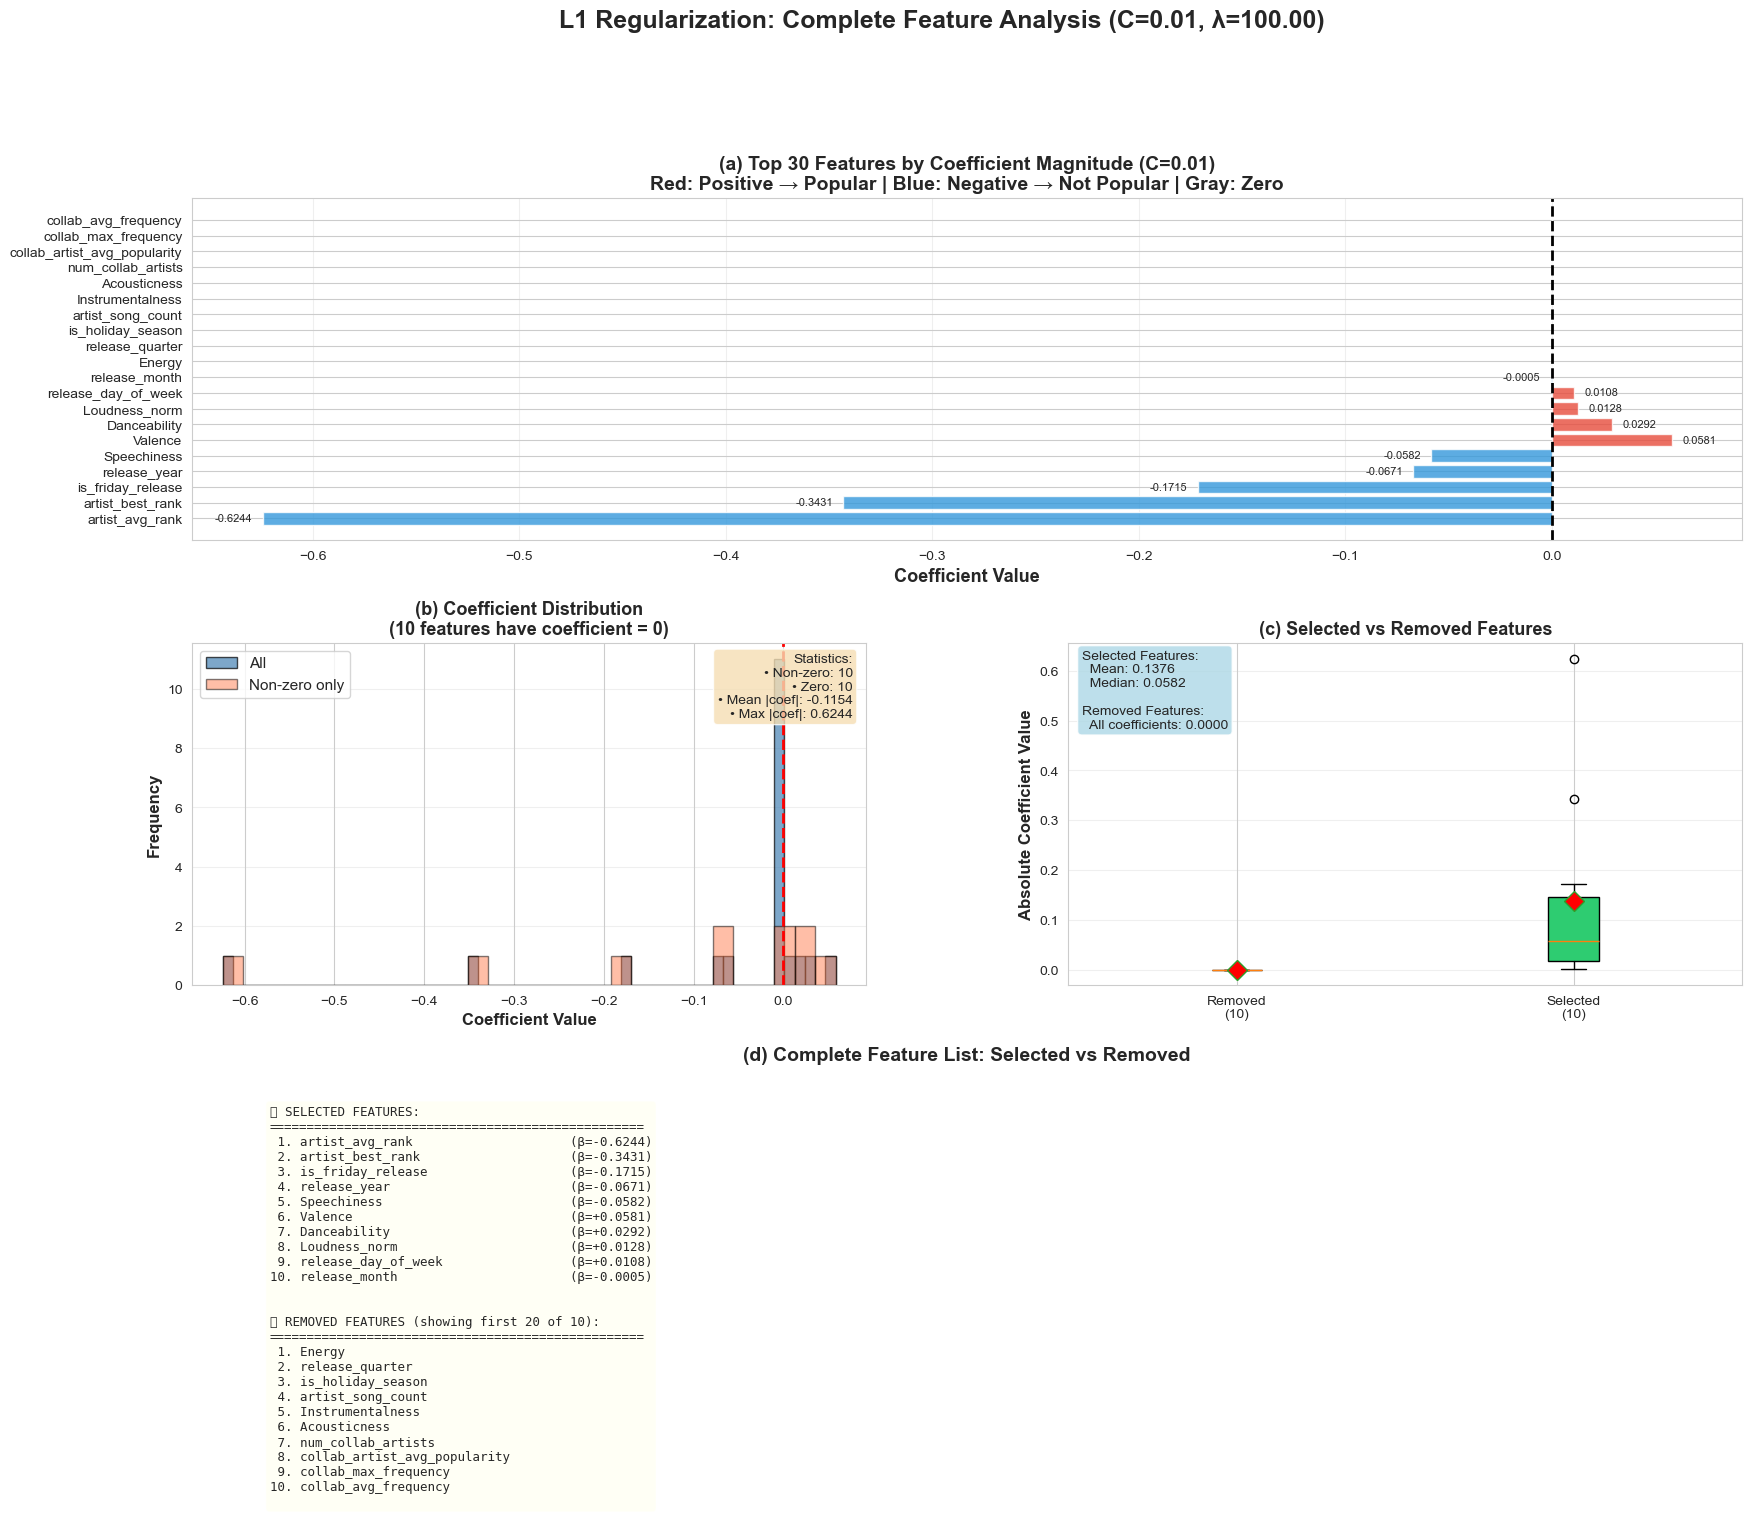


✓ Complete visualization saved: l1_all_features_analysis.png


In [ ]:
all_coefs = lr_l1_best.coef_[0]
all_features = X_train_scaled.columns


all_features_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': all_coefs,
    'Abs_Coefficient': np.abs(all_coefs),
    'Selected': all_coefs != 0,
    'Direction': ['Popular' if c > 0 else 'Not Popular' if c < 0 else 'Removed' 
                  for c in all_coefs]
}).sort_values('Abs_Coefficient', ascending=False)


n_total = len(all_features_df)
n_selected = all_features_df['Selected'].sum()
n_removed = n_total - n_selected

print(f"\n ALL FEATURES SUMMARY (C={best_C})")

print(f"Total features: {n_total}")
print(f"Selected (non-zero): {n_selected}")
print(f"Removed (zero): {n_removed}")
print(f"Selection rate: {n_selected/n_total*100:.1f}%")

print(f"\n TOP 20 FEATURES BY IMPORTANCE:")

print(all_features_df.head(20).to_string(index=False))

print(f"\n BOTTOM 20 FEATURES (Least Important/Removed):")

print(all_features_df.tail(20).to_string(index=False))


fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)


ax1 = fig.add_subplot(gs[0, :])
top30 = all_features_df.head(30)
colors_top30 = ['#e74c3c' if c > 0 else '#3498db' if c < 0 else '#95a5a6' 
                for c in top30['Coefficient']]

bars1 = ax1.barh(range(len(top30)), top30['Coefficient'], color=colors_top30, alpha=0.8)
ax1.set_yticks(range(len(top30)))
ax1.set_yticklabels(top30['Feature'], fontsize=10)
ax1.set_xlabel('Coefficient Value', fontsize=13, fontweight='bold')
ax1.set_title(f'(a) Top 30 Features by Coefficient Magnitude (C={best_C})\n'
              'Red: Positive → Popular | Blue: Negative → Not Popular | Gray: Zero',
              fontsize=14, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=2)
ax1.grid(True, alpha=0.3, axis='x')


for i, (bar, val) in enumerate(zip(bars1, top30['Coefficient'])):
    if val != 0:
        ax1.text(val + (0.005 if val > 0 else -0.005), i, f'{val:.4f}',
                va='center', ha='left' if val > 0 else 'right', fontsize=8)


ax2 = fig.add_subplot(gs[1, 0])
non_zero_coefs = all_coefs[all_coefs != 0]
ax2.hist(all_coefs, bins=60, alpha=0.7, color='steelblue', edgecolor='black', label='All')
ax2.hist(non_zero_coefs, bins=30, alpha=0.5, color='coral', edgecolor='black', label='Non-zero only')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Coefficient Value', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title(f'(b) Coefficient Distribution\n({n_removed} features have coefficient = 0)',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')


stats_text = (f"Statistics:\n"
             f"• Non-zero: {n_selected}\n"
             f"• Zero: {n_removed}\n"
             f"• Mean |coef|: {non_zero_coefs.mean():.4f}\n"
             f"• Max |coef|: {np.abs(all_coefs).max():.4f}")
ax2.text(0.98, 0.97, stats_text, transform=ax2.transAxes,
        fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))


ax3 = fig.add_subplot(gs[1, 1])
selected_abs = all_features_df[all_features_df['Selected']]['Abs_Coefficient']
removed_abs = all_features_df[~all_features_df['Selected']]['Abs_Coefficient']

bp = ax3.boxplot([removed_abs, selected_abs],
                 labels=[f'Removed\n({n_removed})', f'Selected\n({n_selected})'],
                 patch_artist=True, showmeans=True,
                 meanprops=dict(marker='D', markerfacecolor='red', markersize=10))

bp['boxes'][0].set_facecolor('#95a5a6')
bp['boxes'][1].set_facecolor('#2ecc71')

ax3.set_ylabel('Absolute Coefficient Value', fontsize=12, fontweight='bold')
ax3.set_title('(c) Selected vs Removed Features', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')


comp_text = (f"Selected Features:\n"
            f"  Mean: {selected_abs.mean():.4f}\n"
            f"  Median: {selected_abs.median():.4f}\n\n"
            f"Removed Features:\n"
            f"  All coefficients: 0.0000")
ax3.text(0.02, 0.98, comp_text, transform=ax3.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))


ax4 = fig.add_subplot(gs[2, :])


selected_features_list = all_features_df[all_features_df['Selected']]['Feature'].tolist()
removed_features_list = all_features_df[~all_features_df['Selected']]['Feature'].tolist()


n_cols = 4
n_per_col = (n_selected + n_cols - 1) // n_cols  

ax4.axis('off')
ax4.set_title('(d) Complete Feature List: Selected vs Removed', 
             fontsize=14, fontweight='bold', pad=20)


selected_text = "SELECTED FEATURES:\n" + "=" * 50 + "\n"
for i, feat in enumerate(selected_features_list, 1):
    coef = all_features_df[all_features_df['Feature'] == feat]['Coefficient'].values[0]
    selected_text += f"{i:2d}. {feat:<35s} (β={coef:+.4f})\n"

# Display removed features (first 20)
removed_text = f"\n\nREMOVED FEATURES (showing first 20 of {n_removed}):\n" + "=" * 50 + "\n"
for i, feat in enumerate(removed_features_list[:20], 1):
    removed_text += f"{i:2d}. {feat}\n"
if n_removed > 20:
    removed_text += f"\n... and {n_removed - 20} more features"

full_text = selected_text + removed_text

ax4.text(0.05, 0.95, full_text, transform=ax4.transAxes,
        fontsize=9, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.3))

plt.suptitle(f'L1 Regularization: Complete Feature Analysis (C={best_C}, λ={1/best_C:.2f})',
            fontsize=18, fontweight='bold', y=0.998)

plt.savefig('l1_all_features_analysis.png', dpi=300, bbox_inches='tight')
plt.show()



## Step 5: PCA for features

In [ ]:

pca = PCA(n_components=0.95, random_state=42)


X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)


pca_columns = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]
X_train_pca = pd.DataFrame(X_train_pca, columns=pca_columns, index=X_train_scaled.index)
X_val_pca = pd.DataFrame(X_val_pca, columns=pca_columns, index=X_val_scaled.index)
X_test_pca = pd.DataFrame(X_test_pca, columns=pca_columns, index=X_test_scaled.index)

with open('pca_model.pkl', 'wb') as f:
    pickle.dump(pca, f)


print(f"Original features: {X_train_scaled.shape[1]}")
print(f"PCA components: {X_train_pca.shape[1]}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.4f}")
print(f"\nX_train_pca: {X_train_pca.shape}")
print(f"X_val_pca: {X_val_pca.shape}")
print(f"X_test_pca: {X_test_pca.shape}")

✅ PCA complete
Original features: 20
PCA components: 13
Variance explained: 0.9594

X_train_pca: (6158, 13)
X_val_pca: (1414, 13)
X_test_pca: (1589, 13)



--------------------------------------------------------------------------------
Creating variance explanation plot...
--------------------------------------------------------------------------------


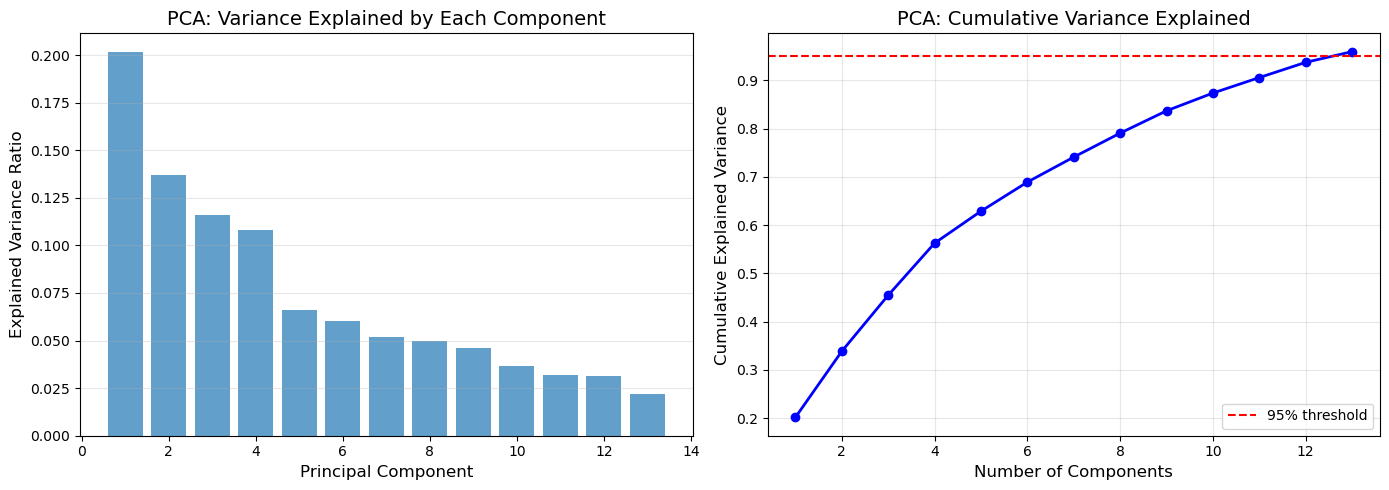

✓ Variance plot saved: pca_variance_explained.png


In [ ]:

n_components = X_train_pca.shape[1]



fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].bar(range(1, n_components + 1), pca.explained_variance_ratio_, alpha=0.7)
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('PCA: Variance Explained by Each Component', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='y')


cumsum = np.cumsum(pca.explained_variance_ratio_)
axes[1].plot(range(1, n_components + 1), cumsum, 'bo-', linewidth=2, markersize=6)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[1].set_title('PCA: Cumulative Variance Explained', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_variance_explained.png', dpi=300, bbox_inches='tight')
plt.show()



## Step 6: Compare Baseline vs PCA vs L1 

In [ ]:

comparison_results = []


y_train_pred_baseline = lr_baseline.predict(X_train_scaled)
y_val_pred_baseline = lr_baseline.predict(X_val_scaled)

baseline_train_acc = accuracy_score(y_train_array, y_train_pred_baseline)
baseline_val_acc = accuracy_score(y_val_array, y_val_pred_baseline)
baseline_train_f1 = f1_score(y_train_array, y_train_pred_baseline)
baseline_val_f1 = f1_score(y_val_array, y_val_pred_baseline)

print(f"Features: {X_train_scaled.shape[1]}")
print(f"Train - Accuracy: {baseline_train_acc:.4f}, F1: {baseline_train_f1:.4f}")
print(f"Val   - Accuracy: {baseline_val_acc:.4f}, F1: {baseline_val_f1:.4f}")

comparison_results.append({
    'Method': 'Baseline (Scaling)',
    'Features': X_train_scaled.shape[1],
    'Train_Acc': baseline_train_acc,
    'Val_Acc': baseline_val_acc,
    'Train_F1': baseline_train_f1,
    'Val_F1': baseline_val_f1
})


lr_l1 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_l1.fit(X_train_L1, y_train_array)

y_train_pred_l1 = lr_l1.predict(X_train_L1)
y_val_pred_l1 = lr_l1.predict(X_val_L1)

l1_train_acc = accuracy_score(y_train_array, y_train_pred_l1)
l1_val_acc = accuracy_score(y_val_array, y_val_pred_l1)
l1_train_f1 = f1_score(y_train_array, y_train_pred_l1)
l1_val_f1 = f1_score(y_val_array, y_val_pred_l1)

print(f"Features: {X_train_L1.shape[1]}")
print(f"Train - Accuracy: {l1_train_acc:.4f}, F1: {l1_train_f1:.4f}")
print(f"Val   - Accuracy: {l1_val_acc:.4f}, F1: {l1_val_f1:.4f}")

comparison_results.append({
    'Method': 'L1 Selection',
    'Features': X_train_L1.shape[1],
    'Train_Acc': l1_train_acc,
    'Val_Acc': l1_val_acc,
    'Train_F1': l1_train_f1,
    'Val_F1': l1_val_f1
})


lr_pca = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_pca.fit(X_train_pca, y_train_array)

y_train_pred_pca = lr_pca.predict(X_train_pca)
y_val_pred_pca = lr_pca.predict(X_val_pca)

pca_train_acc = accuracy_score(y_train_array, y_train_pred_pca)
pca_val_acc = accuracy_score(y_val_array, y_val_pred_pca)
pca_train_f1 = f1_score(y_train_array, y_train_pred_pca)
pca_val_f1 = f1_score(y_val_array, y_val_pred_pca)

print(f"Features: {X_train_pca.shape[1]}")
print(f"Train - Accuracy: {pca_train_acc:.4f}, F1: {pca_train_f1:.4f}")
print(f"Val   - Accuracy: {pca_val_acc:.4f}, F1: {pca_val_f1:.4f}")

comparison_results.append({
    'Method': 'PCA',
    'Features': X_train_pca.shape[1],
    'Train_Acc': pca_train_acc,
    'Val_Acc': pca_val_acc,
    'Train_F1': pca_train_f1,
    'Val_F1': pca_val_f1
})


comparison_df = pd.DataFrame(comparison_results)
print(comparison_df.to_string(index=False))


best_method = comparison_df.loc[comparison_df['Val_F1'].idxmax(), 'Method']
print(f"\nBest Method (Val F1): {best_method}")


1️⃣ BASELINE (Scaling Only)
--------------------------------------------------------------------------------
Features: 20
Train - Accuracy: 0.6453, F1: 0.5599
Val   - Accuracy: 0.6450, F1: 0.3548

2️⃣ L1 FEATURE SELECTION
--------------------------------------------------------------------------------
Features: 10
Train - Accuracy: 0.6393, F1: 0.5537
Val   - Accuracy: 0.6521, F1: 0.3724

3️⃣ PCA (95% Variance)
--------------------------------------------------------------------------------
Features: 13
Train - Accuracy: 0.6440, F1: 0.5556
Val   - Accuracy: 0.6612, F1: 0.3656

SUMMARY COMPARISON
            Method  Features  Train_Acc  Val_Acc  Train_F1   Val_F1
Baseline (Scaling)        20   0.645339 0.644979  0.559855 0.354756
      L1 Selection        10   0.639331 0.652051  0.553747 0.372449
               PCA        13   0.644040 0.661245  0.555556 0.365563

🏆 Best Method (Val F1): L1 Selection


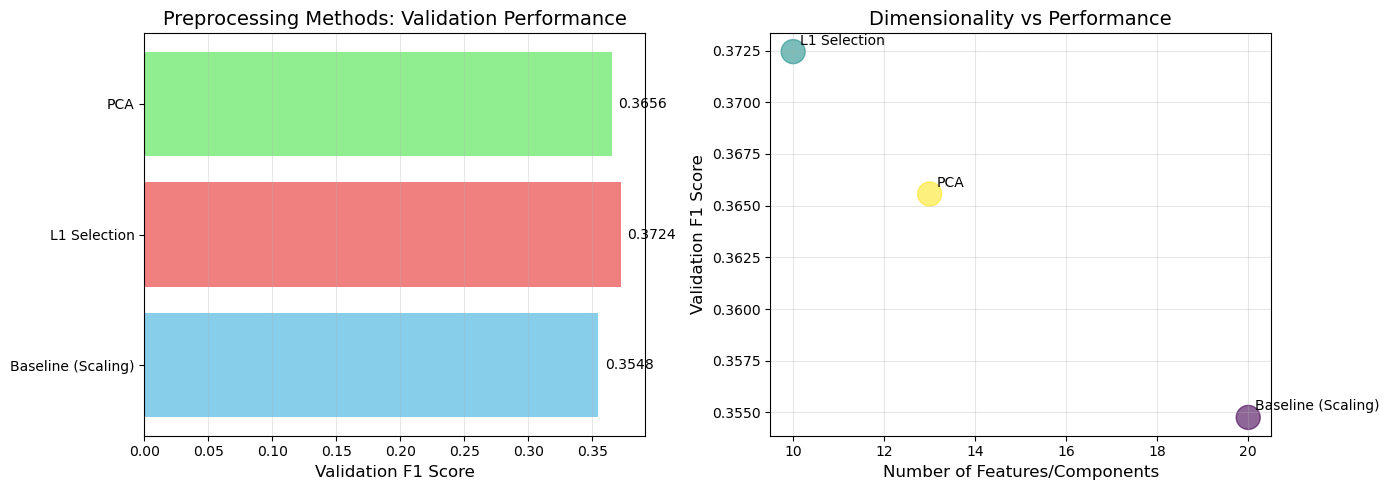

✓ Comparison plot saved: preprocessing_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


methods = comparison_df['Method']
val_f1s = comparison_df['Val_F1']
colors = ['skyblue', 'lightcoral', 'lightgreen']

axes[0].barh(methods, val_f1s, color=colors)
axes[0].set_xlabel('Validation F1 Score', fontsize=12)
axes[0].set_title('Preprocessing Methods: Validation Performance', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='x')


for i, (method, score) in enumerate(zip(methods, val_f1s)):
    axes[0].text(score + 0.005, i, f'{score:.4f}', va='center', fontsize=10)


axes[1].scatter(comparison_df['Features'], comparison_df['Val_F1'], 
               s=300, alpha=0.6, c=range(len(comparison_df)), cmap='viridis')

for idx, row in comparison_df.iterrows():
    axes[1].annotate(row['Method'], 
                    (row['Features'], row['Val_F1']),
                    xytext=(5, 5), textcoords='offset points', fontsize=10)

axes[1].set_xlabel('Number of Features/Components', fontsize=12)
axes[1].set_ylabel('Validation F1 Score', fontsize=12)
axes[1].set_title('Dimensionality vs Performance', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('preprocessing_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


## Step 9: Post process for ML Training
SAVE PROCESSED DATASETS (CSV)

In [ ]:
import pickle
import os


os.makedirs('preprocessing_artifacts', exist_ok=True)




X_train_scaled.to_csv('preprocessing_artifacts/X_train_baseline.csv', index=False)
X_val_scaled.to_csv('preprocessing_artifacts/X_val_baseline.csv', index=False)
X_test_scaled.to_csv('preprocessing_artifacts/X_test_baseline.csv', index=False)


X_train_L1.to_csv('preprocessing_artifacts/X_train_L1.csv', index=False)
X_val_L1.to_csv('preprocessing_artifacts/X_val_L1.csv', index=False)
X_test_L1.to_csv('preprocessing_artifacts/X_test_L1.csv', index=False)

X_train_pca.to_csv('preprocessing_artifacts/X_train_pca.csv', index=False)
X_val_pca.to_csv('preprocessing_artifacts/X_val_pca.csv', index=False)
X_test_pca.to_csv('preprocessing_artifacts/X_test_pca.csv', index=False)

y_train.to_csv('preprocessing_artifacts/y_train.csv', index=False)
y_val.to_csv('preprocessing_artifacts/y_val.csv', index=False)
y_test.to_csv('preprocessing_artifacts/y_test.csv', index=False)



1️⃣ Saving processed datasets...
--------------------------------------------------------------------------------
✓ Baseline datasets saved
✓ L1 feature-selected datasets saved
✓ PCA datasets saved
✓ Target variables saved
